In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from scipy.signal import savgol_filter

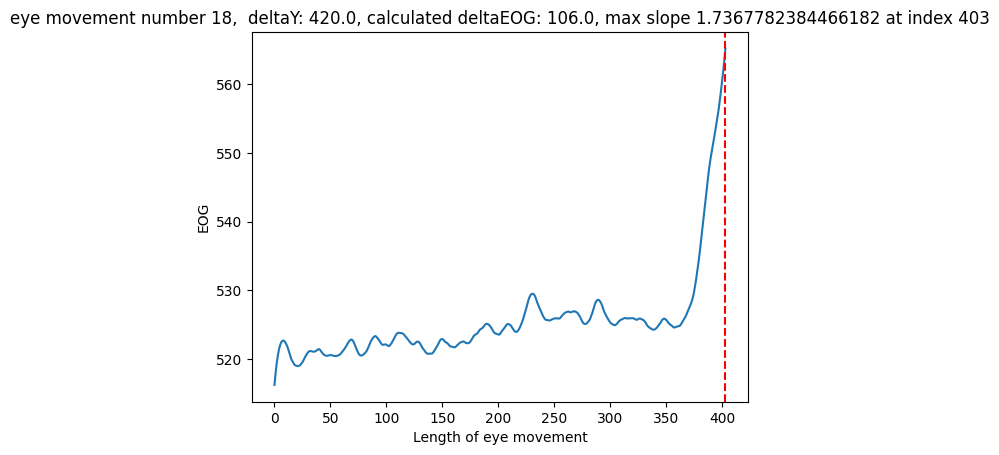

In [ ]:
with open("raw_eye_movements.json") as f: # load the list of random points generated in calibration_game
    raw_mvmt = json.load(f)

with open("deltaY.json") as f:
    deltaY = json.load(f)

with open("deltaEOG_v_eye_movements.json") as f:
    deltaEOG_v = json.load(f)


def get_max_slope(mvmt):
    grad = np.gradient(mvmt)
    return np.max(grad), np.argmax(grad)

def plot_raw_mvmt(num):
    raw_mvmt_smoothed = savgol_filter(raw_mvmt[num], 31, 3)[:404]
    plt.plot(range(0, len(raw_mvmt_smoothed)), raw_mvmt_smoothed)
    plt.axvline(x=get_max_slope(raw_mvmt_smoothed)[1], color='r', linestyle='--')
    plt.title(f'eye movement number {num},  deltaY: {deltaY[num]}, calculated deltaEOG: {deltaEOG_v[num]}, max slope {get_max_slope(raw_mvmt_smoothed)[0]} at index {get_max_slope(raw_mvmt_smoothed)[1]}')
    plt.ylabel('EOG')
    plt.xlabel('Length of eye movement')

plot_raw_mvmt(18)

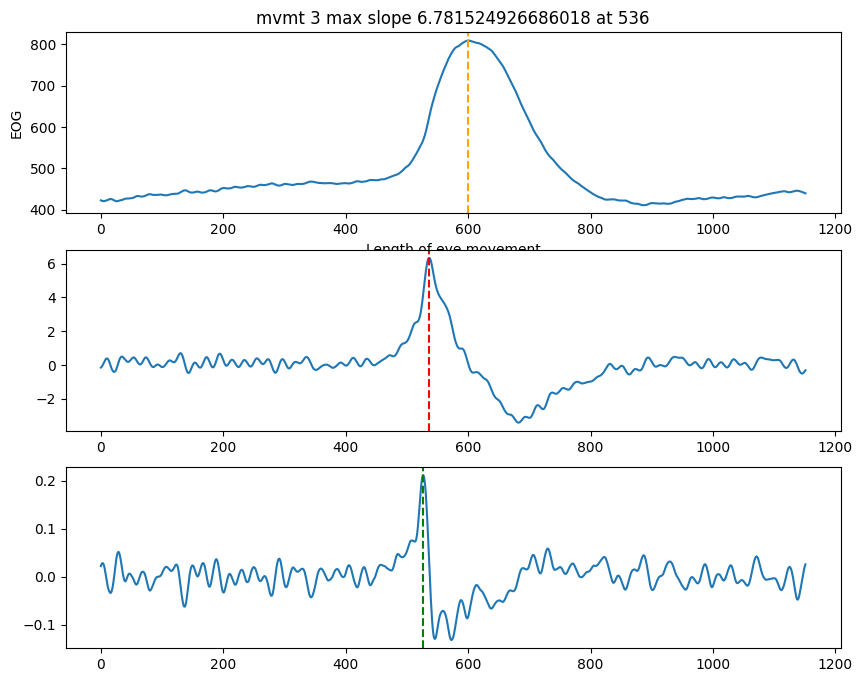

In [276]:
from scipy.signal import savgol_filter

with open ('raw_blinks.json') as f:
    blinks = json.load(f)

def get_max_slope(mvmt): 
    grad = np.gradient(mvmt)
    return np.max(grad), np.argmax(grad)

def get_max_accel(mvmt):
    d2 = np.gradient(np.gradient(mvmt))
    return np.max(d2), np.argmax(d2)

def plot_mvmt(data, num, bounds):
    if bounds == None:
        bounds = (0, len(data[num]) - 1)
    mvmt = savgol_filter(data[num], 31, 3)[bounds[0] : bounds[1]]
    fig, ax = plt.subplots(3, 1, figsize=(10, 8))

    v = savgol_filter(mvmt, 31, 3, deriv=1, mode='nearest')
    a = savgol_filter(mvmt, 31, 3, deriv=2, mode='nearest')

    ax[0].plot(range(0, len(mvmt)), mvmt)
    ax[1].plot(range(0, len(mvmt)), v)
    ax[2].plot(range(0, len(mvmt)), a)
    ax[0].axvline(x = np.argmax(mvmt), color = 'orange', linestyle = '--')
    ax[1].axvline(x = np.argmax(v), color='r', linestyle='--')
    ax[2].axvline(x = np.argmax(a), color = 'g', linestyle = '--')
    ax[0].set_title(f'mvmt {num} max slope {get_max_slope(mvmt)[0]} at {get_max_slope(mvmt)[1]}')
    ax[0].set_ylabel('EOG')
    ax[0].set_xlabel('Length of eye movement')

plot_mvmt(blinks, 3, None)




max deltaEOG in blink: 345.02892102334715 at window (np.int64(399), np.int64(599)) with max slope 6.344780023804049 with acceleration 0.2112684376824154


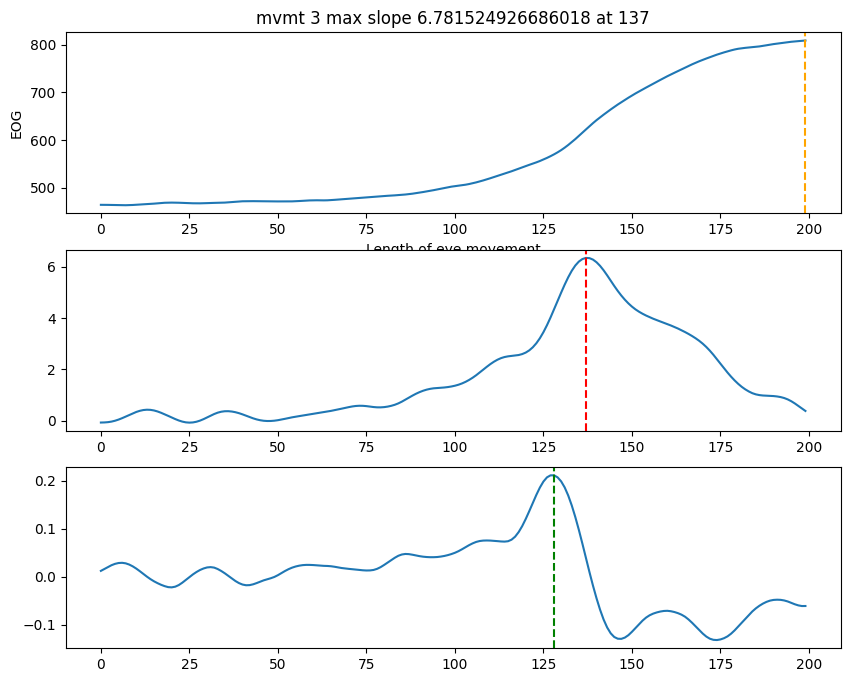

In [274]:
def examine_window(data, num):

    mvmt = data[num]

    deltaEOG_blinks = np.array([])

    # use sliding window to get the max deltaEOG, then return the min of those max deltaEOG's as our threshold.
    if data == raw_mvmt:
        window_size = 150
    else:
        window_size = 200
    i = 0
    window_deltas_y = []
    
    mvmt = savgol_filter(mvmt, 31, 3)
    v = savgol_filter(mvmt, 31, 3, deriv=1)
    a = savgol_filter(mvmt, 31, 3, deriv=2)

    original_argmax = np.argmax(mvmt)

    mvmt = mvmt[:original_argmax]
    v = v[:original_argmax]
    a = a[:original_argmax]  # only look at the part of the blink up to slightly after the max point

    for i in range(len(mvmt) - window_size):
        # signal went down first, then up → positive saccade
        window_deltas_y.append(max(mvmt[i: i + window_size]) - min(mvmt[i:i+ window_size]))

    max_diff_loc = np.argmax(window_deltas_y)
    deltaEOG = max(window_deltas_y)
    window_bounds_of_max_diff = (max_diff_loc, max_diff_loc + window_size)
    max_slope_within_window = max(v[window_bounds_of_max_diff[0] : window_bounds_of_max_diff[1]])
    max_accel_within_window = max(a[window_bounds_of_max_diff[0] : window_bounds_of_max_diff[1]])

    print(f'max deltaEOG in blink: {deltaEOG} at window {window_bounds_of_max_diff} with max slope {max_slope_within_window} with acceleration {max_accel_within_window}')

    plot_mvmt(data, num, window_bounds_of_max_diff)
    return deltaEOG, max_slope_within_window, max_accel_within_window


deltaEOG, max_slope_within_window, max_accel_within_window = examine_window(blinks, 3)

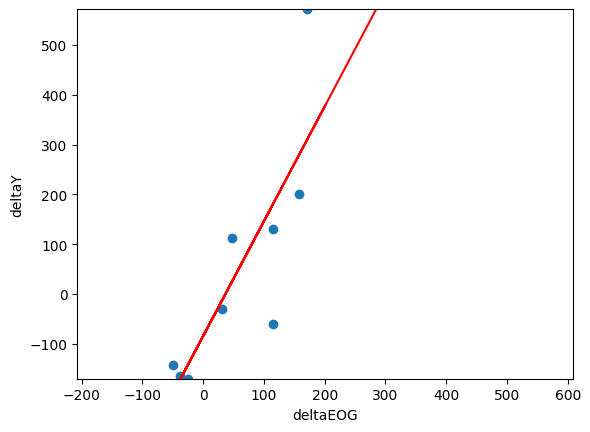

In [335]:
with open("deltaEOG_v_eye_movements.json") as f: # load the list of random points generated in calibration_game
    deltaEOG_V = json.load(f)

with open("deltaY.json") as f: # load the list of random points generated in calibration_game
    deltaY = json.load(f)

with open('linear_model_coefficients.json') as f:
    model_coef = json.load(f)

plt.scatter(deltaEOG_V, deltaY)
plt.xlabel('deltaEOG')
plt.ylabel('deltaY')
plt.ylim((min(deltaY), max(deltaY)))
slope = model_coef['slope']
intercept = model_coef['intercept']
plt.plot(deltaY, slope * np.array(deltaY) + intercept, color='red', label='Line of Best Fit')   


In [332]:
with open('rt.json') as f:
    rt = json.load(f)

blinks = [i for i, x in enumerate(rt) if x == 'blink']
print(blinks)

blink_num = 7
print(rt[blinks[blink_num]], rt[blinks[blink_num] - 5])


[31, 148, 208, 433, 450, 491, 525, 561, 620]
blink -28.64110268733873


### Make a method to analyze any window